In [11]:
import pandas as pd
data=pd.read_csv('/content/flight destination svm classification.csv')
data.head(2)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,Destination,price
0,11/2/2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953
1,11/2/2022,SpiceJet,SG,8157,6:20,Delhi,02h 20m,non-stop,8:40,Mumbai,5953


In [13]:
data['Destination'].replace(['Bangalore','Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai'],[0,1,2,3,4,5],inplace=True)

In [8]:
X=data[['num_code','price']]
y=data['Destination']
x=X.iloc[:10000,:]
y=y.iloc[:10000]

In [9]:
from sklearn.metrics import accuracy_score
from sklearn import svm
svc=svm.SVC(kernel='linear', C=1).fit(x, y) #linear kernel
svc_pred = svc.predict(x)
print('svc accuracy', accuracy_score(y,svc_pred)*100)
#linear svc
lin_svc=svm.LinearSVC(C=1).fit(x, y)
lin_pred = svc.predict(x)
print('svc accuracy', accuracy_score(y,lin_pred)*100)
#rbf kernel
rbf_svc=svm.SVC(kernel='rbf', gamma=.7, C=1).fit(x, y)
rbf_pred = svc.predict(x)
print('svc accuracy', accuracy_score(y,rbf_pred)*100)
#poly kernel
poly_svc=svm.SVC(kernel='poly', degree=3, C=1).fit(x, y)
poly_pred = svc.predict(x)
print('svc accuracy', accuracy_score(y,poly_pred)*100)

svc accuracy 99.83999999999999
svc accuracy 99.83999999999999
svc accuracy 99.83999999999999
svc accuracy 99.83999999999999


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


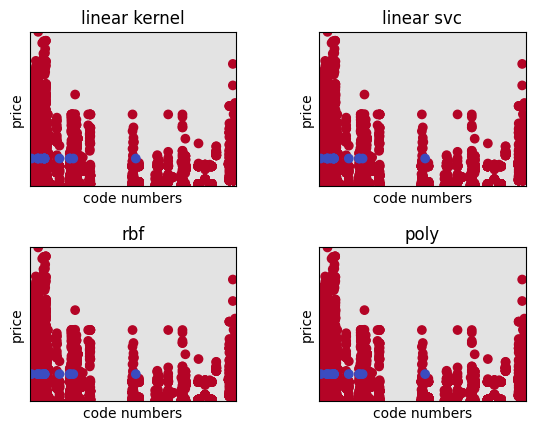

In [10]:
import numpy as np
import matplotlib.pyplot as plt

h=10
x_min, x_max = x.iloc[:, 0].min() - 1, x.iloc[:, 0].max() + 1  #num_code over x axis
y_min, y_max = x.iloc[:, 1].min() - 1, x.iloc[:, 1].max() + 1  #price over y axis
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

titles=['linear kernel','linear svc','rbf','poly']

for i, clf in enumerate((svc, lin_svc, rbf_svc, poly_svc)):
    # create 4 subplots
    plt.subplot(2,2,i+1)
    plt.subplots_adjust(wspace=0.4,hspace=0.4)

    # predict destinations based on num_code and price
    Z=clf.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)

    # plot actual and predicted values
    plt.contourf(xx,yy,Z,cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(x.iloc[:,0],x.iloc[:,1], c=y, cmap=plt.cm.coolwarm)

    # modify the graphs by adding labels, titles, ...
    plt.xlabel('code numbers')
    plt.ylabel('price')
    plt.xlim(xx.min(),xx.max())
    plt.ylim(yy.min(),yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

plt.show()